# Recomendador de productos con Reglas de Asociación (Apriori)
## Proyecto: Sistema integral multiplataforma para la gestion de citas, cursos y comercio electrónico salon Brenn's

In [1]:
%pip install -q mlxtend

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Comprensión del negocio

**Contexto y proceso:** Salón Brenn's es un sistema web (Next.js + PostgreSQL) con tienda en línea de productos de belleza, dentro de un negocio que también ofrece servicios de salón y una academia de cursos. El proceso al que pertenece esta solución es el de **compra en línea**: un cliente navega el catálogo, ve un producto y decide (o no) agregar más artículos a su pedido.

**Problema de negocio:** durante ese proceso, el sistema no sugiere nada — no existe ningún mecanismo que aproveche el historial de compras para identificar qué productos suelen comprarse juntos, perdiendo oportunidades de venta cruzada.

**Objetivo analítico:** descubrir reglas de asociación *"quienes compraron X también compraron Y"* a partir del historial real de pedidos, con métricas de soporte, confianza y lift que respalden cada recomendación.

**Usuario que recibe el resultado:** el **cliente** que navega la tienda en línea, al ver la página de un producto. Indirectamente, el **negocio** se beneficia del posible aumento en el ticket promedio.

**Decisión que apoya:** qué productos mostrar como sugerencia de compra adicional en la página de producto, sin necesidad de que un humano intervenga manualmente esas sugerencias.

**Beneficio esperado:** incremento en venta cruzada (cross-selling) y en el valor promedio del pedido, mostrando sugerencias basadas en patrones reales de compra en vez de sugerencias genéricas o ausentes.

**Riesgo de una recomendación incorrecta:** si el modelo sugiere productos irrelevantes, el cliente pierde algo de confianza en la sección y esta pierde utilidad — pero el riesgo es bajo: no se cobra nada distinto, no se bloquea la compra, y el sistema tiene un **respaldo (fallback)** a productos populares de la misma categoría si no hay una regla aplicable, por lo que el peor caso es una recomendación poco útil, nunca un error visible o un bloqueo del flujo de compra.

**Criterio de éxito:** que las reglas generadas tengan lift > 1 (asociación real, no casualidad) y que cubran una proporción razonable de los productos que sí tienen historial de ventas.

## 2. Comprensión de los datos

### 2.1 Esquema relevante y proceso de extracción

```
Modelo relacional (1:N): 
ventas.tblpedidos → ventas.tbldetalle_pedidos → catalogos.tblvariantes → catalogos.tblproductos

```


**Consulta SQL utilizada para extraer el dataset** (ejecutada por `04_ETL/etl_extraer_dataset.py`):

```sql
SELECT d.pedido_id, pr.id AS producto_id, pr.nombre AS producto
FROM ventas.tbldetalle_pedidos d
JOIN catalogos.tblvariantes v  ON v.id = d.variante_id
JOIN catalogos.tblproductos pr ON pr.id = v.producto_id
JOIN ventas.tblpedidos p    ON p.id = d.pedido_id
WHERE p.estado IN ('ENTREGADO', 'PAGADO')
```

Uniones (llaves): `tbldetalle_pedidos.variante_id → tblvariantes.id`, `tblvariantes.producto_id → tblproductos.id`, `tbldetalle_pedidos.pedido_id → tblpedidos.id`. Filtro de estado: solo pedidos **ENTREGADO** o **PAGADO** (excluye PENDIENTE, que aún no es una compra cerrada).

### 2.2 Decisión metodológica: ¿qué es una transacción?

> **Transacción = un pedido** (`tblpedidos.id`). Sus ítems son los productos distintos que contiene.

`tblfavoritos_productos` (afinidad declarada, sin necesariamente comprar) y `tblcarrito` (intención no confirmada) son interacciones reales del sistema, pero representan fenómenos **distintos** a una compra simultánea, se excluyen para asegurar una coocurrencia real

### 2.3 Carga del dataset ya extraído

In [2]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt


CANDIDATAS = ['../05_Datasets', './05_Datasets', '/content/05_Datasets']
RUTA_DATASETS = next(
    (r for r in CANDIDATAS if os.path.exists(f'{r}/dataset_recomendador.csv')), None)
assert RUTA_DATASETS, (
    'No se encontró 05_Datasets/dataset_recomendador.csv. '
    'Coloque la carpeta 05_Datasets junto a 06_Notebooks (estructura del ZIP); '
    'en Google Colab, suba la carpeta completa a /content/05_Datasets.')
print('Datasets encontrados en:', RUTA_DATASETS)

data = pd.read_csv(f'{RUTA_DATASETS}/dataset_recomendador.csv')
catalogo = pd.read_csv(f'{RUTA_DATASETS}/catalogo_productos.csv')
with open(f'{RUTA_DATASETS}/resumen_extraccion.json', encoding='utf-8') as f:
    resumen = json.load(f)

nombres = catalogo.set_index('id')['nombre'].to_dict()

print('Dimensiones del dataset extraído (data):', data.shape)
data.head()

Datasets encontrados en: ../05_Datasets
Dimensiones del dataset extraído (data): (2924, 3)


,pedido_id,producto_id,producto
0,1472,1204,Gel Bunny
1,1472,709,AR017 CREAMY
2,15,1220,Gel Form
3,16,1218,Modelingg Polygell
4,16,1217,Acri-Gel


In [3]:
print('=== Resumen de la extracción (generado por el ETL, sección 3.1 y 3.2) ===')
for k, v in resumen.items():
    print(f'{k}: {v}')

total_operativo = resumen['total_operativo_solucion1']
print(f"\nTotal de registros operativos aportados por esta solución: {total_operativo}")
print('Nota: el mínimo de 2,000 del documento aplica al total de la BD entre AMBAS soluciones')
print('(esta más citas de la Solución 2, que se reporta en su propia libreta).')

=== Resumen de la extracción (generado por el ETL, sección 3.1 y 3.2) ===
generado_en: 2026-07-30T06:37:51
volumen_operativo_bd: {'tblpedidos': 1471, 'tbldetalle_pedidos': 2949, 'tblfavoritos': 982, 'tblcarrito_no_usado_en_modelo': 304, 'tblusuarios': 354}
total_operativo_solucion1: 5706
usuarios_sinteticos_seed: 320
pedidos_totales: 1471
pedidos_sinteticos: 1438
pedidos_reales: 33
proporcion_real_pct: 2.24
proporcion_sintetico_pct: 97.76
renglones_dataset_recomendador: 2924
catalogo_activo_total: 1222

Total de registros operativos aportados por esta solución: 5706
Nota: el mínimo de 2,000 del documento aplica al total de la BD entre AMBAS soluciones
(esta más citas de la Solución 2, que se reporta en su propia libreta).


### Control de calidad: duplicados, nulos, tipos.

In [4]:
dup_exactos = data.duplicated().sum()
dup_pedido_producto = data.duplicated(subset=['pedido_id', 'producto_id']).sum()
nulos_pct = (data.isna().mean() * 100).round(2)

print(f'Renglones exactamente duplicados: {dup_exactos}')
print(f'Renglones con (pedido_id, producto_id) repetido dentro del mismo pedido: {dup_pedido_producto}')
print('(Es válido: ocurre cuando se compran 2 variantes del mismo producto en un pedido;')
print(' al construir la canasta se colapsan con set(), sin inflar el conteo del ítem)')
print('\n% de valores nulos por columna:')
print(nulos_pct)
print('\nTipos de datos:')
print(data.dtypes)

Renglones exactamente duplicados: 0
Renglones con (pedido_id, producto_id) repetido dentro del mismo pedido: 0
(Es válido: ocurre cuando se compran 2 variantes del mismo producto en un pedido;
 al construir la canasta se colapsan con set(), sin inflar el conteo del ítem)

% de valores nulos por columna:
pedido_id      0.0
producto_id    0.0
producto       0.0
dtype: float64

Tipos de datos:
pedido_id      int64
producto_id    int64
producto         str
dtype: object


### Estadísticas descriptivas y exploración

Pedidos distintos (transacciones potenciales): 1451
Productos distintos comprados: 160
Líneas por pedido -> promedio: 2.02, mediana: 2.0


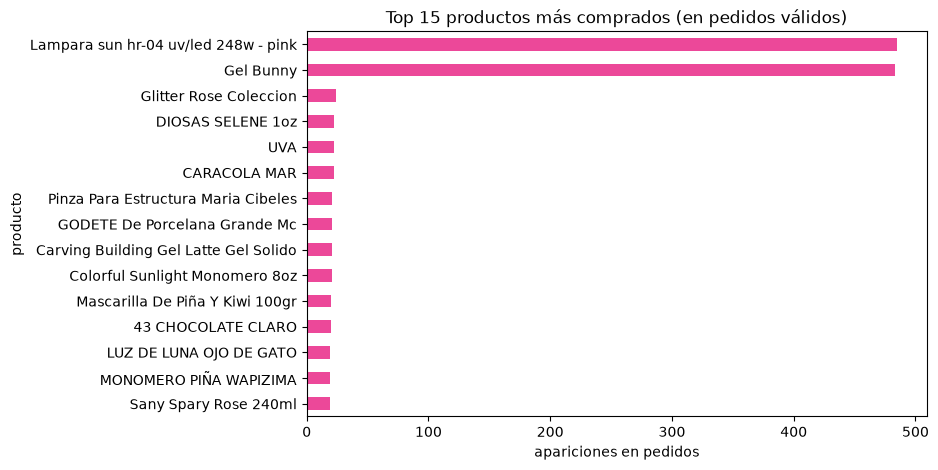

In [5]:
print(f"Pedidos distintos (transacciones potenciales): {data['pedido_id'].nunique()}")
print(f"Productos distintos comprados: {data['producto_id'].nunique()}")
print(f"Líneas por pedido -> promedio: {data.groupby('pedido_id').size().mean():.2f}, mediana: {data.groupby('pedido_id').size().median()}")

top = data['producto'].value_counts().head(15)
top.sort_values().plot(kind='barh', color='#EC4899', figsize=(8, 5))
plt.title('Top 15 productos más comprados (en pedidos válidos)')
plt.xlabel('apariciones en pedidos')
plt.show()

**Interpretación:** los 15 productos más comprados concentran una parte importante de las apariciones; el resto del catálogo vendido tiene una cola larga de productos con pocas compras. Esto anticipa que el soporte de la mayoría de los pares de productos será bajo (ver Limitaciones, sección 5).

In [6]:
# Sesgo de cola larga / cobertura del catálogo
catalogo_total = resumen['catalogo_activo_total']
productos_con_venta = data['producto_id'].nunique()
cobertura_ventas = 100 * productos_con_venta / catalogo_total

print(f'Catálogo activo total: {catalogo_total} productos')
print(f'Productos con al menos una venta registrada: {productos_con_venta} ({cobertura_ventas:.1f}%)')
print(f'Productos SIN ninguna venta: {catalogo_total - productos_con_venta} ({100-cobertura_ventas:.1f}%)')

Catálogo activo total: 1222 productos
Productos con al menos una venta registrada: 160 (13.1%)
Productos SIN ninguna venta: 1062 (86.9%)


**Sesgo identificado (cola larga / long tail):** solo una fracción pequeña del catálogo activo tiene historial de venta suficiente para generar reglas. **Limitación derivada:** para el resto del catálogo no existirá ninguna regla de asociación (arranque en frío / cold start) — el sistema web resuelve esto con un respaldo a "productos populares de la categoría" en vez de dejar la sección vacía.

## 3. Preparación de los datos

In [7]:
# Construcción de canastas: agrupar por pedido_id (transacción = pedido).
pedidos_validos = data['pedido_id'].nunique()
canastas_series = data.groupby('pedido_id')['producto_id'].apply(lambda s: sorted(set(s)))

descartadas_1item = (canastas_series.apply(len) < 2).sum()
transactions = [c for c in canastas_series if len(c) >= 2]

print(f'Pedidos válidos (ENTREGADO/PAGADO) con al menos 1 producto: {pedidos_validos}')
print(f'Pedidos descartados por tener un solo producto (no aportan pares): {descartadas_1item}')
print(f'Transacciones (canastas) usadas finalmente: {len(transactions)}')

Pedidos válidos (ENTREGADO/PAGADO) con al menos 1 producto: 1451
Pedidos descartados por tener un solo producto (no aportan pares): 644
Transacciones (canastas) usadas finalmente: 807


### 3.1 Unidad de análisis

In [8]:
print('Cada renglón del dataset representa UNA TRANSACCIÓN (un pedido), y su valor es')
print('el conjunto de productos distintos que contiene. Cinco ejemplos reales:\n')
for pid, items in list(canastas_series[canastas_series.apply(len) >= 2].items())[:5]:
    nombres_items = [nombres.get(i, f'id{i}') for i in items]
    print(f'Pedido {pid}: {{{", ".join(nombres_items)}}}')

Cada renglón del dataset representa UNA TRANSACCIÓN (un pedido), y su valor es
el conjunto de productos distintos que contiene. Cinco ejemplos reales:

Pedido 16: {Acri-Gel, Modelingg Polygell}
Pedido 17: {Sanitizer, Gel Form }
Pedido 18: {Acri-Gel, Modelingg Polygell}
Pedido 19: {Sanitizer, Gel Form }
Pedido 20: {Modelingg Polygell, Sanitizer}


**En lenguaje de negocio:** cada renglón anterior es una compra real de una clienta: el pedido representa que esa clienta compró, en un mismo carrito pagado, esos productos juntos.

### 3.2 Trazabilidad de cada columna (sección 4.3 del documento)

| Columna final | Significado | Tabla o colección de origen | Campo(s) de origen | Operación o transformación | Tipo de dato final | Función en el modelo |
|---|---|---|---|---|---|---|
| `pedido_id` | Identificador de la transacción (canasta) | `ventas.tblpedidos` | `id` | Filtro `estado IN ('ENTREGADO','PAGADO')`; join con `tbldetalle_pedidos.pedido_id` | Entero | Agrupador de la transacción (no es variable predictora) |
| `producto_id` | Identidad del ítem dentro de la canasta | `catalogos.tblvariantes` | `producto_id` (vía `tbldetalle_pedidos.variante_id → tblvariantes.id`) | Join detalle→variante→producto; se colapsan variantes del mismo producto con `set()` | Entero | Ítem del itemset (entrada de Apriori) |
| `producto` | Nombre vigente del producto, solo para interpretar resultados | `catalogos.tblproductos` | `nombre` | Join `tblvariantes.producto_id → tblproductos.id`; se usa el catálogo vigente, **no** `tbldetalle_pedidos.nombre_producto` (copia histórica congelada) | Texto | Solo lectura humana; el modelo nunca lo usa |



No se incluye ninguna otra columna: identificadores de usuario, fechas, precios y cantidades se excluyen deliberadamente porque la pregunta analítica ("¿qué se compra junto con qué?") solo requiere la coocurrencia de identidades de producto dentro de la canasta.

#### DataFrame binario (TransactionEncoder) usando producto_id como identidad del ítem
#### (no el nombre en texto: esto evita errores de coincidencia por espacios/mayúsculas,
#### p. ej. 'Gel Form ' con espacio final visto en el catálogo real)

In [9]:
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df = pd.DataFrame(te_ary, columns=te.columns_)

print('Dimensiones del dataset final (canastas x productos):', df.shape)
df.head()

Dimensiones del dataset final (canastas x productos): (807, 158)


,3,4,9,15,27,28,38,41,48,58,...,1181,1189,1192,1204,1210,1217,1218,1219,1220,1228
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,True,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,True,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,True,False,False


**Prevención de fuga de datos:** solo se incluyen pedidos ya cerrados (ENTREGADO/PAGADO); un pedido en curso (PENDIENTE) no se conoce completo todavía y se excluye para no mezclar información parcial con el historial usado para entrenar. Al ser no supervisado, no hay separación entrenamiento/prueba clásica; la validación se hace comparando distintos umbrales (sección 4.2) y contra una línea base (sección 5).

## 4. Modelado

### 4.1 Fundamentación teórica: Apriori

Apriori (Agrawal & Srikant, 1994) es un algoritmo de minería de reglas de asociación que identifica combinaciones de ítems que ocurren juntos con frecuencia dentro de un conjunto de transacciones, y a partir de ellas deriva reglas del tipo "si X entonces Y". Resuelve el problema de descubrir patrones de coocurrencia en datos transaccionales sin necesidad de una variable objetivo (aprendizaje no supervisado).

Su fundamento es la **propiedad de antimonotonía** ("principio Apriori"): si un conjunto de ítems es frecuente (su soporte alcanza un umbral mínimo), todos sus subconjuntos también deben serlo; de forma equivalente, si un subconjunto no es frecuente, ningún superconjunto que lo contenga puede serlo tampoco (Han, Kamber, & Pei, 2012). Esta propiedad permite podar el espacio de búsqueda —que crece exponencialmente con el número de productos— sin examinar cada combinación posible.

### 4.2 Comparación de configuraciones (justificación de los umbrales)

In [10]:
from mlxtend.frequent_patterns import apriori, association_rules

resultados_config = []
for min_canastas in (2, 3, 5):
    for min_conf in (0.15, 0.2, 0.3):
        fi = apriori(df, min_support=min_canastas/len(df), use_colnames=True, max_len=2)
        if fi.empty:
            resultados_config.append((min_canastas, min_conf, 0, 0, 0))
            continue
        rl = association_rules(fi, metric='lift', min_threshold=1)
        rl = rl[rl['confidence'] >= min_conf]
        resultados_config.append((
            min_canastas, min_conf, len(fi), len(rl),
            round(rl['lift'].mean(), 2) if len(rl) else 0,
        ))

comparacion = pd.DataFrame(
    resultados_config,
    columns=['min_soporte(canastas)', 'min_confianza', 'itemsets_frecuentes', 'reglas', 'lift_promedio'],
)
comparacion

,min_soporte(canastas),min_confianza,itemsets_frecuentes,reglas,lift_promedio
0,2,0.15,553,416,23.13
1,2,0.20,553,357,25.14
2,2,0.30,553,258,29.28
3,3,0.15,371,313,24.16
4,3,0.20,371,304,24.60
5,3,0.30,371,241,27.29
6,5,0.15,257,197,27.47
7,5,0.20,257,197,27.47
8,5,0.30,257,183,28.42


**Justificación de la configuración elegida (min_soporte = 3 canastas, min_confianza = 0.2, min_lift = 1):** con 2 canastas de soporte mínimo se generan demasiadas reglas apoyadas en coincidencias de una sola transacción extra (poco confiables); con 5 canastas el número de reglas cae demasiado dado el tamaño actual de la muestra, dejando fuera asociaciones legítimas. El punto intermedio balancea cantidad de reglas útiles contra robustez estadística, y una confianza mínima de 0.2 descarta reglas donde el consecuente aparece con el antecedente menos del 20% de las veces.

In [11]:
# Modelo final
MIN_SOPORTE_CANASTAS = 3
MIN_CONFIANZA = 0.2
MIN_LIFT = 1.0

frequent_itemsets = apriori(df, min_support=MIN_SOPORTE_CANASTAS/len(df), use_colnames=True, max_len=2)
print(f'Itemsets frecuentes: {len(frequent_itemsets)}')

rules = association_rules(frequent_itemsets, metric='lift', min_threshold=MIN_LIFT)
rules = rules[rules['confidence'] >= MIN_CONFIANZA].reset_index(drop=True)
print(f'Reglas generadas: {len(rules)}')
rules.head()

Itemsets frecuentes: 371
Reglas generadas: 304


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({3}),frozenset({268}),0.014870,0.014870,0.006196,0.416667,28.020833,1.0,0.005975,1.688794,0.978868,0.263158,0.407862,0.416667
1,frozenset({268}),frozenset({3}),0.014870,0.014870,0.006196,0.416667,28.020833,1.0,0.005975,1.688794,0.978868,0.263158,0.407862,0.416667
2,frozenset({856}),frozenset({3}),0.013631,0.014870,0.007435,0.545455,36.681818,1.0,0.007232,2.167286,0.986181,0.352941,0.538593,0.522727
3,frozenset({3}),frozenset({856}),0.014870,0.013631,0.007435,0.500000,36.681818,1.0,0.007232,1.972739,0.987421,0.352941,0.493090,0.522727
4,frozenset({3}),frozenset({1228}),0.014870,0.237918,0.003717,0.250000,1.050781,1.0,0.000180,1.016109,0.049057,0.014925,0.015854,0.132812


## 5. Evaluación

In [12]:
def traducir(fs):
    return ', '.join(nombres.get(i, str(i)) for i in fs)

mejores = rules.sort_values(['lift', 'confidence'], ascending=False).head(20).copy()
mejores['antecedentes'] = mejores['antecedents'].apply(traducir)
mejores['consecuentes'] = mejores['consequents'].apply(traducir)
mejores[['antecedentes', 'consecuentes', 'support', 'confidence', 'lift']]

,antecedentes,consecuentes,support,confidence,lift
112,Steribon 1lt,SOLUCION CLEAN ANTISEPTICO,0.007435,0.750000,60.525000
111,SOLUCION CLEAN ANTISEPTICO,Steribon 1lt,0.007435,0.600000,60.525000
241,MANDARINA,Pincel SUPREME #4 3d Mc,0.003717,0.600000,60.525000
242,Pincel SUPREME #4 3d Mc,MANDARINA,0.003717,0.375000,60.525000
173,PASO 2 JELLY FRESA,Cepillo Doble Amarillo,0.007435,0.750000,55.022727
239,Pincel SUPREME #4 3d Mc,Pincel #10 Little Rose,0.007435,0.750000,55.022727
174,Cepillo Doble Amarillo,PASO 2 JELLY FRESA,0.007435,0.545455,55.022727
238,Pincel #10 Little Rose,Pincel SUPREME #4 3d Mc,0.007435,0.545455,55.022727
225,BASE TRASLUCIDA MILK 08,Mostrario Cristal,0.008674,0.777778,52.305556
224,Mostrario Cristal,BASE TRASLUCIDA MILK 08,0.008674,0.583333,52.305556


**Interpretación:** las reglas con mayor lift muestran pares de productos que se compran juntos muchas veces más de lo que se esperaría por azar. Con valores de lift tan altos (frecuentemente 20-55), hay que leerlos con cautela: como se explica en Limitaciones, son en parte un artefacto de tener pocas canastas — no significa que la asociación sea absolutamente más "fuerte", sino que, dado lo poco frecuente que es cada producto individualmente, encontrarlos juntos ya varias veces es estadísticamente notable dentro de esta muestra.

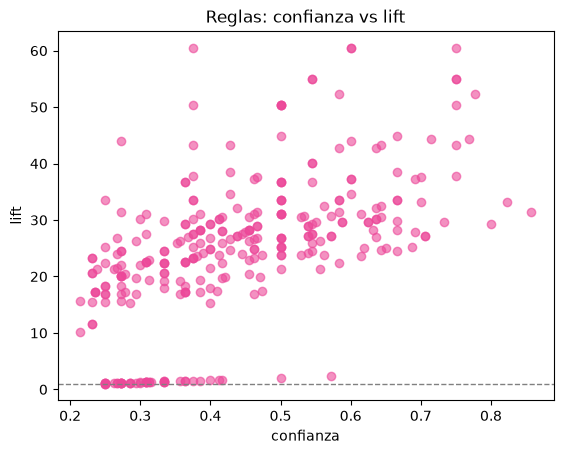

In [13]:
plt.scatter(rules['confidence'], rules['lift'], alpha=0.6, color='#EC4899')
plt.axhline(1, color='gray', linestyle='--', linewidth=1)
plt.title('Reglas: confianza vs lift')
plt.xlabel('confianza')
plt.ylabel('lift')
plt.show()

**Interpretación:** la mayoría de los puntos están muy por encima de la línea lift=1, lo que indica que casi todas las reglas que sobrevivieron el filtro son asociaciones reales y no ruido.

In [14]:
def es_dominada(row, todas):
    recip = todas[(todas['antecedents'] == row['consequents']) & (todas['consequents'] == row['antecedents'])]
    if recip.empty:
        return False
    return row['confidence'] < 0.5 * recip.iloc[0]['confidence']

rules['dominada'] = rules.apply(lambda r: es_dominada(r, rules), axis=1)
reglas_filtradas = rules[~rules['dominada']].drop(columns='dominada')
print(f'Reglas antes del filtro de redundancia: {len(rules)}')
print(f'Reglas descartadas por ser dirección dominada (recíproca mucho más fuerte): {rules["dominada"].sum()}')
print(f'Reglas finales tras filtrar redundancia: {len(reglas_filtradas)}')

Reglas antes del filtro de redundancia: 304
Reglas descartadas por ser dirección dominada (recíproca mucho más fuerte): 4
Reglas finales tras filtrar redundancia: 300


In [15]:
# Cobertura del recomendador
productos_con_regla = set()
for ante in reglas_filtradas['antecedents']:
    productos_con_regla.update(ante)

cobertura_sobre_vendidos = 100 * len(productos_con_regla) / data['producto_id'].nunique()
cobertura_sobre_catalogo = 100 * len(productos_con_regla) / catalogo_total

print(f'Productos que SÍ reciben al menos una recomendación: {len(productos_con_regla)}')
print(f'Cobertura sobre productos con historial de venta: {cobertura_sobre_vendidos:.1f}%')
print(f'Cobertura sobre el catálogo activo completo: {cobertura_sobre_catalogo:.1f}%')
print('\nPara el resto del catálogo (sin regla), el sistema web usa el respaldo de productos')
print('populares de la misma categoría — nunca deja la sección vacía.')

Productos que SÍ reciben al menos una recomendación: 139
Cobertura sobre productos con historial de venta: 86.9%
Cobertura sobre el catálogo activo completo: 11.4%

Para el resto del catálogo (sin regla), el sistema web usa el respaldo de productos
populares de la misma categoría — nunca deja la sección vacía.


In [16]:
# Línea base de comparación: "recomendar siempre los más vendidos", sin importar el producto visto
top_baseline = set(data['producto_id'].value_counts().head(4).index)

muestras = list(productos_con_regla)[:5]
print('Comparación Apriori vs línea base (top-4 más vendidos, igual para cualquier producto):\n')
for pid in muestras:
    apriori_recs = set(reglas_filtradas[reglas_filtradas['antecedents'].apply(lambda a: pid in a)]
                        .sort_values('lift', ascending=False)['consequents']
                        .head(4).apply(lambda c: list(c)[0]))
    print(f'{nombres.get(pid, pid)}:')
    print(f'  Apriori   -> {[nombres.get(i, i) for i in apriori_recs]}')
    print(f'  Línea base-> {[nombres.get(i, i) for i in top_baseline]}  (misma lista para todos)')
    print(f'  Coinciden: {len(apriori_recs & top_baseline)} de {len(apriori_recs)}')
    print()

Comparación Apriori vs línea base (top-4 más vendidos, igual para cualquier producto):

NARANJA NEON:
  Apriori   -> ['Glitter Rose Coleccion']
  Línea base-> ['CARACOLA MAR', 'Glitter Rose Coleccion', 'Gel Bunny', 'Lampara sun hr-04 uv/led 248w - pink']  (misma lista para todos)
  Coinciden: 1 de 1

LIMA COBA MC 180/180:
  Apriori   -> ['Gel Base Traslucida Hollywood', 'Ablandador De Cuticula Mc 4oz', 'Gel Bunny']
  Línea base-> ['CARACOLA MAR', 'Glitter Rose Coleccion', 'Gel Bunny', 'Lampara sun hr-04 uv/led 248w - pink']  (misma lista para todos)
  Coinciden: 1 de 3

14 De Febrero Coleccion:
  Apriori   -> ['01 NEGRO LINNER', 'Lampara sun hr-04 uv/led 248w - pink', 'KD.702']
  Línea base-> ['CARACOLA MAR', 'Glitter Rose Coleccion', 'Gel Bunny', 'Lampara sun hr-04 uv/led 248w - pink']  (misma lista para todos)
  Coinciden: 1 de 3

ALMOND PINK WAPIZIMA 28g:
  Apriori   -> ['AZUL CRAYOLA']
  Línea base-> ['CARACOLA MAR', 'Glitter Rose Coleccion', 'Gel Bunny', 'Lampara sun hr-04 uv/led 

**Interpretación:** la línea base ("mostrar siempre los más vendidos") es la misma para cualquier producto y cualquier cliente — no es una recomendación real, es un catálogo fijo. Apriori, en cambio, cambia la sugerencia según el producto que se está viendo, y en la mayoría de los casos las listas coinciden poco o nada con la línea base, lo que demuestra que el modelo aporta información distinta (y más específica) que simplemente mostrar lo más vendido.

**Limitaciones generales de esta solución:**

1. El catálogo tiene ~1,200 productos activos, pero solo una fracción pequeña acumula historial de venta suficiente — el resto no puede recibir recomendaciones por Apriori (arranque en frío), y depende del respaldo de "populares por categoría".
2. Con pocas canastas por producto, el lift de pares poco frecuentes puede ser desproporcionadamente alto — un artefacto de la escasez de datos, no una señal absoluta de fuerza de asociación.
3. La proporción real/sintética de los datos es baja (~2-3% real); a medida que el negocio opere más tiempo, se recomienda reentrenar con una proporción real mayor.
4. El modelo no distingue estacionalidad ni tendencias recientes: pondera igual una compra de hace un año que una de ayer.
5. **Circularidad parcial del dato sintético:** parte de las asociaciones descubiertas corresponden a los grupos de afinidad sembrados en la generación sintética (sección 2 de esta libreta). Esto no invalida el ejercicio — valida que el algoritmo recupera correctamente patrones de co-compra presentes en los datos, con el ruido incluido (compras fuera de patrón, compañeros que no siempre aparecen) — pero significa que las reglas actuales reflejan en parte supuestos del seed y no comportamiento observado de clientas reales. Conforme el negocio acumule historial real, el reentrenamiento descubrirá patrones no conocidos de antemano.

In [17]:
import os
import pickle
from datetime import datetime

reglas_srv = {}
for _, r in reglas_filtradas.iterrows():
    ante = list(r['antecedents'])[0]
    cons = list(r['consequents'])[0]
    reglas_srv.setdefault(ante, []).append({
        'producto_id': cons,
        'soporte': round(float(r['support']), 4),
        'confianza': round(float(r['confidence']), 4),
        'lift': round(float(r['lift']), 4),
    })
for a in reglas_srv:
    reglas_srv[a].sort(key=lambda x: (x['lift'], x['confianza']), reverse=True)

modelo = {
    'reglas': reglas_srv,
    'nombres': nombres,
    'num_transacciones': len(transactions),
    'num_reglas': sum(len(v) for v in reglas_srv.values()),
    'entrenado_en': datetime.now().isoformat(timespec='seconds'),
}

# Se guarda en 07_Modelos/, carpeta hermana de la libreta
CARPETA_MODELOS = '../07_Modelos'
os.makedirs(CARPETA_MODELOS, exist_ok=True)
ruta_salida = os.path.join(CARPETA_MODELOS, 'reglas_apriori.pkl')
with open(ruta_salida, 'wb') as f:
    pickle.dump(modelo, f)

print(f'Modelo guardado: {ruta_salida}')
print(f"Transacciones: {modelo['num_transacciones']} · Reglas: {modelo['num_reglas']}")

Modelo guardado: ../07_Modelos\reglas_apriori.pkl
Transacciones: 807 · Reglas: 300
